In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# ===========================
# USER PARAMETERS
# ===========================

# Domain (same as your solver)
L = 2*np.pi
B = 2*np.pi

# Reynolds Number
nu = 0.1
Re = 1/nu

# Simulation time
T = 0.125

# Grid
Nxp = 100
Nyp = 100

# Grid spacing
h = L/Nxp

print(f"Re = {Re}")
print(f"Grid = {Nxp} x {Nyp}")
print(f"Time = {T}")

Re = 10.0
Grid = 100 x 100
Time = 0.125


In [3]:
def vorticity_exact(x, y, t, Re):
    '''
    Exact non-dimensional Taylor-Green vorticity
    '''
    decay = np.exp(-2*t/Re)
    return 2*np.sin(x)*np.sin(y)*decay

In [4]:
# Generate grid
X, Y = np.meshgrid(
    np.linspace(0, L, Nxp, endpoint=False),
    np.linspace(0, B, Nyp, endpoint=False),
    indexing="ij"
)

# Exact vorticity matrix
W0 = vorticity_exact(X, Y, 0, Re)
vmax = np.max(np.abs(W0))
vmin = -vmax

W = vorticity_exact(X, Y, T, Re)

print("Shape :", W.shape)
print("Maximum :", np.max(W))
print("Minimum :", np.min(W))
print("Average :", np.mean(W))

Shape : (100, 100)
Maximum : 1.9506198240566652
Minimum : -1.9506198240566652
Average : -4.973799150320701e-18


In [8]:
W_EXACT = []

for t in np.arange(0, 1, 0.0125):
    W = vorticity_exact(X, Y, t, Re)

    W_EXACT.append(W)

In [8]:
W_EXACT_RE = []

for RE in [10, 20, 50, 100]:
    W = vorticity_exact(X, Y, t, Re)

    W_EXACT_RE.append(W)

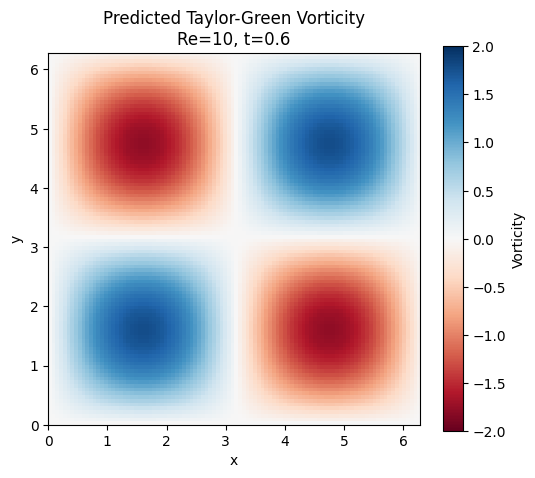

In [10]:
plt.figure(figsize=(6,5))

plt.imshow(
    W,
    extent=[0, L, 0, B],
    origin="lower",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Predicted Taylor-Green Vorticity\nRe={1/nu:.0f}, t={T}")

plt.show()

Fourier Mode Analysis
Vorticity matrix shape : (100, 100)
Nx                     : 100
Ny                     : 100
dx                     : 6.283185e-02
dy                     : 6.283185e-02


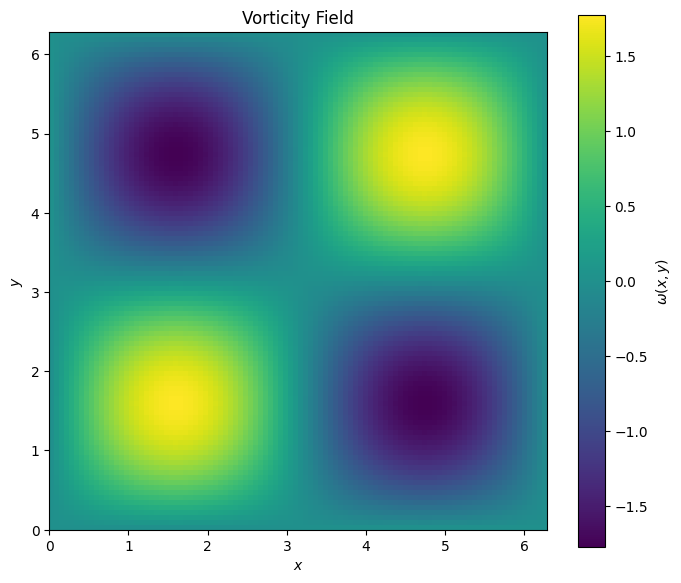

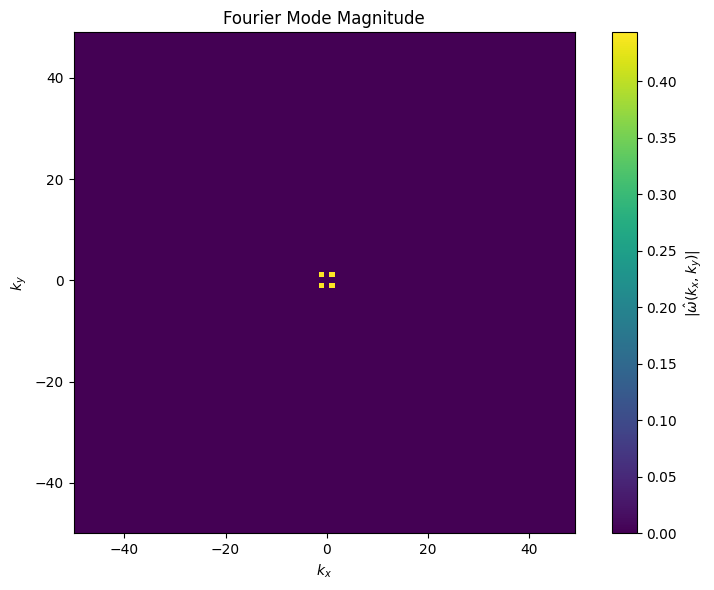

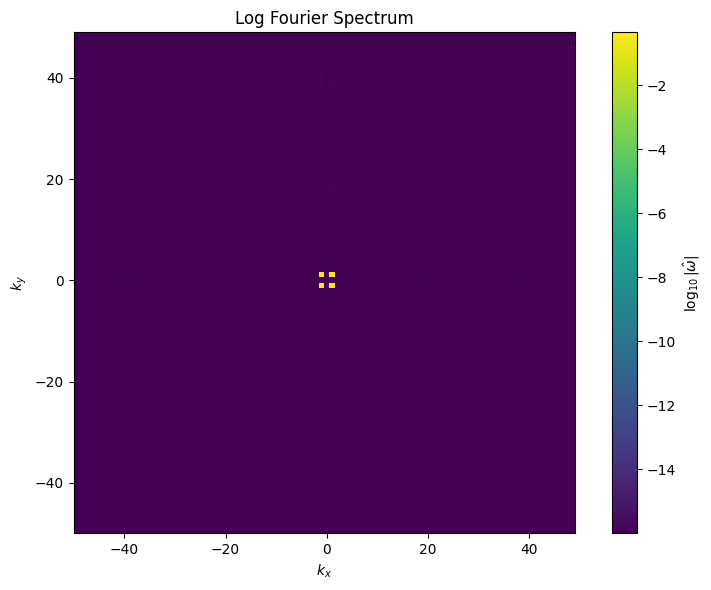

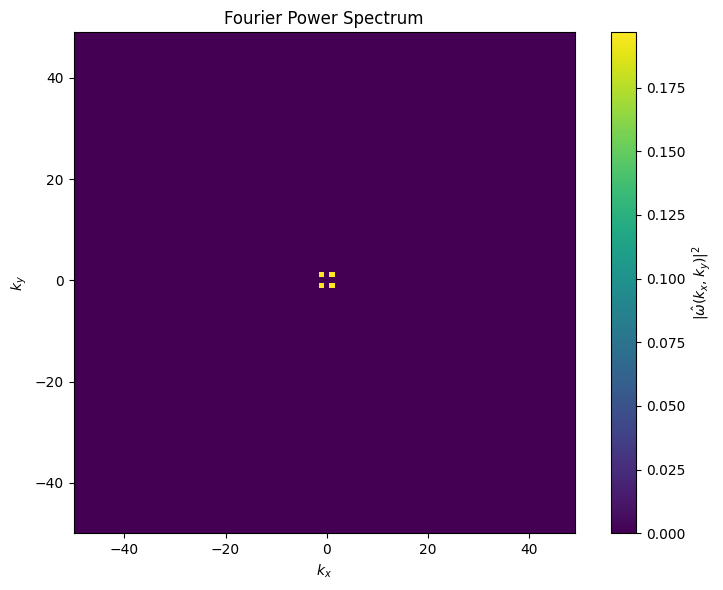

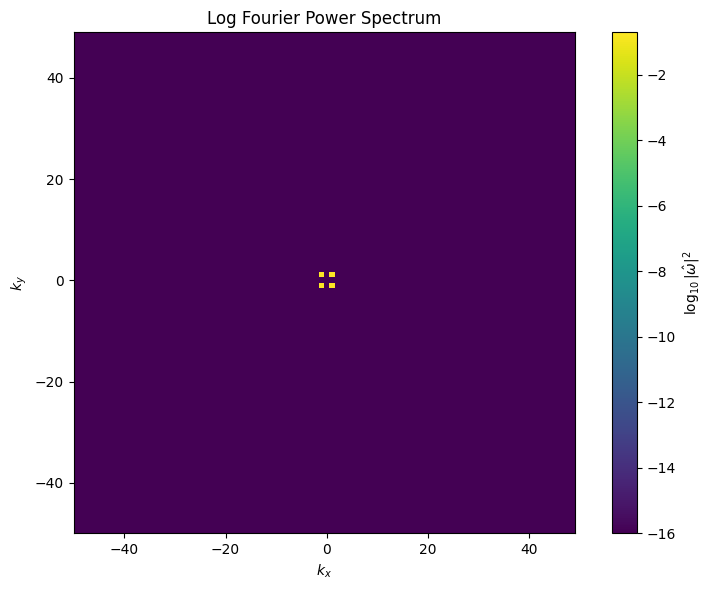

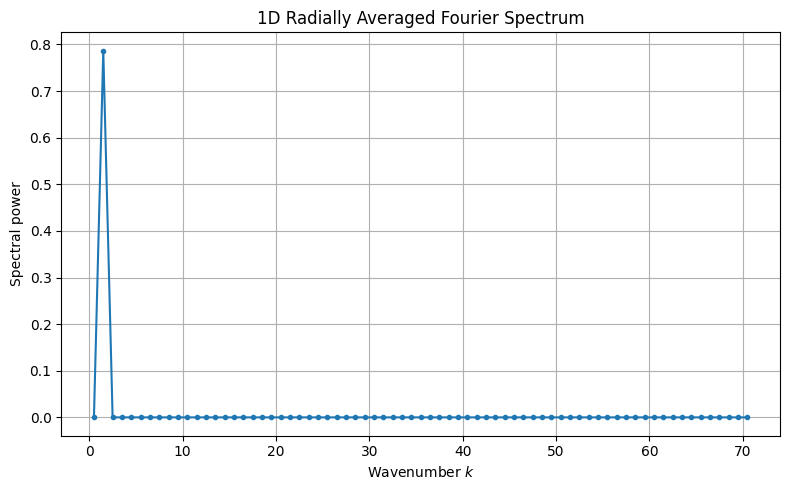

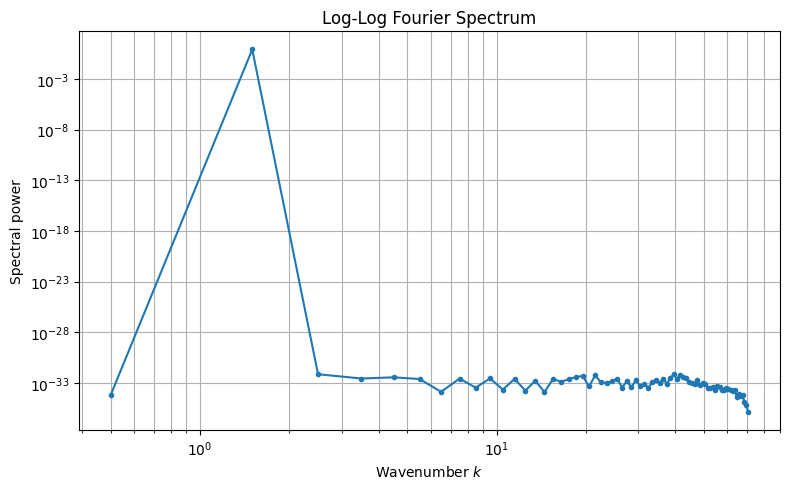



Dominant Fourier Modes
Rank    kx        ky        |omega_hat|       
------------------------------------------------------------
1       1.00      -1.00     4.434602e-01      
2       -1.00     -1.00     4.434602e-01      
3       -1.00     1.00      4.434602e-01      
4       1.00      1.00      4.434602e-01      
5       39.00     1.00      4.912144e-17      
6       39.00     -1.00     4.616684e-17      
7       19.00     1.00      4.092333e-17      
8       -41.00    1.00      3.981655e-17      
9       5.00      1.00      3.648326e-17      
10      1.00      -21.00    3.543299e-17      
11      -21.00    1.00      3.536141e-17      
12      41.00     -1.00     3.496401e-17      
13      15.00     1.00      3.210985e-17      
14      -1.00     -21.00    3.149295e-17      
15      1.00      2.00      3.132162e-17      


Strongest Fourier Mode
kx                 = 1.0000
ky                 = -1.0000
|omega_hat|        = 4.434602e-01


Spectral Statistics
Total spectral power = 7

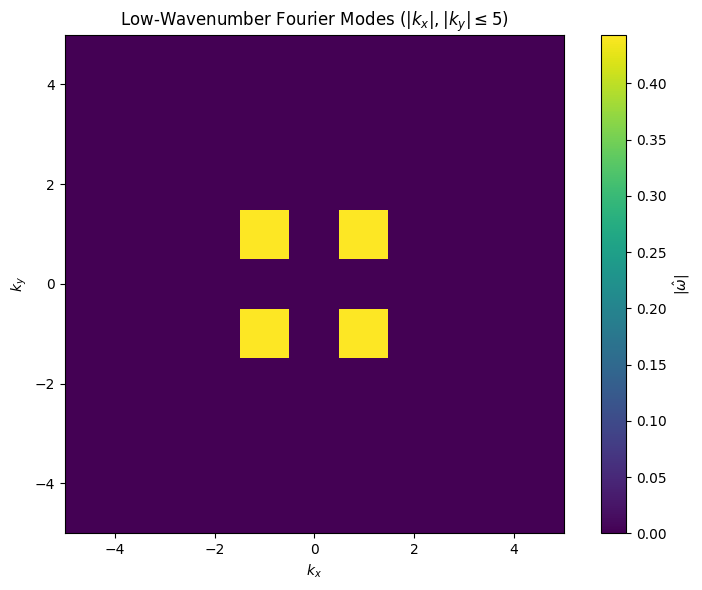



Analysis Complete


In [11]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FOURIER MODE ANALYSIS OF A 2D VORTICITY FIELD
# ============================================================

# ------------------------------------------------------------
# 1. INPUT YOUR VORTICITY MATRIX HERE
# ------------------------------------------------------------

# Example:
# omega = wm

# Replace this with your actual matrix
omega = W


# ------------------------------------------------------------
# 2. DOMAIN PARAMETERS
# ------------------------------------------------------------

# Your Taylor-Green domain
L = 2 * np.pi       # domain length in x
B = 2 * np.pi       # domain length in y

Nx, Ny = omega.shape

dx = L / Nx
dy = B / Ny

print("============================================================")
print("Fourier Mode Analysis")
print("============================================================")
print(f"Vorticity matrix shape : {omega.shape}")
print(f"Nx                     : {Nx}")
print(f"Ny                     : {Ny}")
print(f"dx                     : {dx:.6e}")
print(f"dy                     : {dy:.6e}")


# ------------------------------------------------------------
# 3. PHYSICAL-SPACE GRID
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy

X, Y = np.meshgrid(x, y, indexing="ij")


# ------------------------------------------------------------
# 4. ORIGINAL VORTICITY FIELD
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    omega,
    extent=[0, L, 0, B],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$\omega(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Vorticity Field")

plt.tight_layout()
plt.show()


# ============================================================
# FOURIER TRANSFORM
# ============================================================

# ------------------------------------------------------------
# 5. 2D FFT
# ------------------------------------------------------------

omega_hat = np.fft.fft2(omega)

# Shift zero-frequency mode to the center
omega_hat_shifted = np.fft.fftshift(omega_hat)


# ------------------------------------------------------------
# 6. WAVENUMBERS
# ------------------------------------------------------------

kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

kx_shifted = np.fft.fftshift(kx)
ky_shifted = np.fft.fftshift(ky)

KX, KY = np.meshgrid(
    kx_shifted,
    ky_shifted,
    indexing="ij"
)


# ------------------------------------------------------------
# 7. NORMALIZED FOURIER COEFFICIENTS
# ------------------------------------------------------------

# Normalization makes the coefficient magnitude independent
# of the number of grid points.

omega_hat_normalized = omega_hat / (Nx * Ny)

omega_hat_shifted_normalized = np.fft.fftshift(
    omega_hat_normalized
)


# ============================================================
# FOURIER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 8. FOURIER MODE MAGNITUDE
# ------------------------------------------------------------

fourier_magnitude = np.abs(
    omega_hat_shifted_normalized
)

plt.figure(figsize=(8, 6))

plt.imshow(
    fourier_magnitude,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$|\hat{\omega}(k_x,k_y)|$")

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Mode Magnitude")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. LOG FOURIER SPECTRUM
# ------------------------------------------------------------

# Log scale makes weak modes visible.

log_spectrum = np.log10(
    fourier_magnitude + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# POWER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 10. FOURIER POWER
# ------------------------------------------------------------

power_spectrum = fourier_magnitude ** 2

plt.figure(figsize=(8, 6))

plt.imshow(
    power_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$|\hat{\omega}(k_x,k_y)|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. LOG POWER SPECTRUM
# ------------------------------------------------------------

log_power = np.log10(
    power_spectrum + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_power,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# RADIAL / 1D FOURIER SPECTRUM
# ============================================================

# This converts the 2D spectrum into a spectrum as a function
# of total wavenumber:
#
#       k = sqrt(kx^2 + ky^2)
#
# This is often the most useful spectrum for turbulence analysis.


# ------------------------------------------------------------
# 12. WAVENUMBER MAGNITUDE
# ------------------------------------------------------------

K = np.sqrt(KX**2 + KY**2)


# ------------------------------------------------------------
# 13. CREATE WAVENUMBER BINS
# ------------------------------------------------------------

k_max = int(np.ceil(K.max()))

k_bins = np.arange(
    0,
    k_max + 1
)

k_spectrum = np.zeros(len(k_bins) - 1)


# ------------------------------------------------------------
# 14. BIN FOURIER POWER
# ------------------------------------------------------------

for i in range(len(k_bins) - 1):

    mask = (
        (K >= k_bins[i]) &
        (K < k_bins[i + 1])
    )

    k_spectrum[i] = np.sum(
        power_spectrum[mask]
    )


k_values = 0.5 * (
    k_bins[:-1] +
    k_bins[1:]
)


# ------------------------------------------------------------
# 15. PLOT 1D RADIAL SPECTRUM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_spectrum,
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")
plt.title("1D Radially Averaged Fourier Spectrum")

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. LOG-LOG RADIAL SPECTRUM
# ------------------------------------------------------------

# Ignore zero values for log-log plotting.

mask = k_spectrum > 0

plt.figure(figsize=(8, 5))

plt.loglog(
    k_values[mask],
    k_spectrum[mask],
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")

plt.title("Log-Log Fourier Spectrum")

plt.grid(True, which="both")

plt.tight_layout()
plt.show()


# ============================================================
# DOMINANT FOURIER MODES
# ============================================================

# ------------------------------------------------------------
# 17. FIND LARGEST MODES
# ------------------------------------------------------------

magnitude_original = np.abs(
    omega_hat_normalized
)

flat_indices = np.argsort(
    magnitude_original.ravel()
)[::-1]


print("\n")
print("============================================================")
print("Dominant Fourier Modes")
print("============================================================")

print(
    f"{'Rank':<8}"
    f"{'kx':<10}"
    f"{'ky':<10}"
    f"{'|omega_hat|':<18}"
)

print("------------------------------------------------------------")


number_of_modes = 15

for rank, flat_index in enumerate(
    flat_indices[:number_of_modes],
    start=1
):

    i, j = np.unravel_index(
        flat_index,
        magnitude_original.shape
    )

    print(
        f"{rank:<8}"
        f"{kx[i]:<10.2f}"
        f"{ky[j]:<10.2f}"
        f"{magnitude_original[i,j]:<18.6e}"
    )


# ============================================================
# STRONGEST MODE
# ============================================================

# ------------------------------------------------------------
# 18. SINGLE STRONGEST MODE
# ------------------------------------------------------------

max_index = np.unravel_index(
    np.argmax(magnitude_original),
    magnitude_original.shape
)

i_max, j_max = max_index

dominant_kx = kx[i_max]
dominant_ky = ky[j_max]

dominant_value = magnitude_original[
    i_max,
    j_max
]


print("\n")
print("============================================================")
print("Strongest Fourier Mode")
print("============================================================")

print(f"kx                 = {dominant_kx:.4f}")
print(f"ky                 = {dominant_ky:.4f}")

print(
    f"|omega_hat|        = "
    f"{dominant_value:.6e}"
)


# ============================================================
# TOTAL SPECTRAL POWER
# ============================================================

# ------------------------------------------------------------
# 19. TOTAL POWER
# ------------------------------------------------------------

total_power = np.sum(
    power_spectrum
)

print("\n")
print("============================================================")
print("Spectral Statistics")
print("============================================================")

print(
    f"Total spectral power = "
    f"{total_power:.6e}"
)


# ============================================================
# CHECK FOR ZERO MODE
# ============================================================

# The zero mode represents the spatial mean of vorticity.

zero_mode = omega_hat_normalized[0, 0]

mean_vorticity = np.mean(omega)

print(
    f"Mean vorticity       = "
    f"{mean_vorticity:.6e}"
)

print(
    f"Zero Fourier mode    = "
    f"{zero_mode.real:.6e}"
)


# ============================================================
# OPTIONAL: SHOW ONLY LOW WAVENUMBER MODES
# ============================================================

# This is particularly useful for Taylor-Green vortex,
# because the important modes are usually at small k.

k_limit = 5

low_k_mask = (
    (np.abs(KX) <= k_limit) &
    (np.abs(KY) <= k_limit)
)

low_k_spectrum = np.where(
    low_k_mask,
    fourier_magnitude,
    np.nan
)

plt.figure(figsize=(8, 6))

plt.imshow(
    low_k_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.xlim(-k_limit, k_limit)
plt.ylim(-k_limit, k_limit)

plt.colorbar(
    label=r"$|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")

plt.title(
    f"Low-Wavenumber Fourier Modes "
    f"($|k_x|,|k_y| \leq {k_limit}$)"
)

plt.tight_layout()
plt.show()


print("\n")
print("============================================================")
print("Analysis Complete")
print("============================================================")

In [10]:
import pickle
import os

if os.path.exists("data.pkl"):
    with open("data.pkl", "rb") as f:
        data = pickle.load(f)
else:
    data = {}

data["exact"] = W_EXACT[-1]

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)


data["exact_list"] = W_EXACT

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

"""data["exact_list_re"] = W_EXACT_RE

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)"""

'data["exact_list_re"] = W_EXACT_RE\n\nwith open("data.pkl", "wb") as f:\n    pickle.dump(data, f)'